<a href="https://colab.research.google.com/github/Hemang-Dave/ML-and-Deep-Learning/blob/Kaggle/CLassification_of_MRI_Alzheimer_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import kagglehub
import os
import glob
import numpy as np
import tensorflow as tf
from tqdm import tqdm
import matplotlib.pyplot as plt

# Download latest version
path = kagglehub.dataset_download("uraninjo/augmented-alzheimer-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'augmented-alzheimer-mri-dataset' dataset.
Path to dataset files: /kaggle/input/augmented-alzheimer-mri-dataset


Label mapping: {'MildDemented': 0, 'ModerateDemented': 1, 'NonDemented': 2, 'VeryMildDemented': 3}
Found 896 images in /root/.cache/kagglehub/datasets/uraninjo/augmented-alzheimer-mri-dataset/versions/1/OriginalDataset/MildDemented
Found 64 images in /root/.cache/kagglehub/datasets/uraninjo/augmented-alzheimer-mri-dataset/versions/1/OriginalDataset/ModerateDemented
Found 3200 images in /root/.cache/kagglehub/datasets/uraninjo/augmented-alzheimer-mri-dataset/versions/1/OriginalDataset/NonDemented
Found 2240 images in /root/.cache/kagglehub/datasets/uraninjo/augmented-alzheimer-mri-dataset/versions/1/OriginalDataset/VeryMildDemented
Stratified split summary:
MildDemented       | Train:  716, Test:  180
ModerateDemented   | Train:   51, Test:   13
NonDemented        | Train: 2560, Test:  640
VeryMildDemented   | Train: 1792, Test:  448
Total Train: 5119, Total Test: 1281

Starting training...
Step    1/3000  Loss: 1.3863  Train batch acc: 0.1289
Step  200/3000  Loss: 0.9848  Train batch a

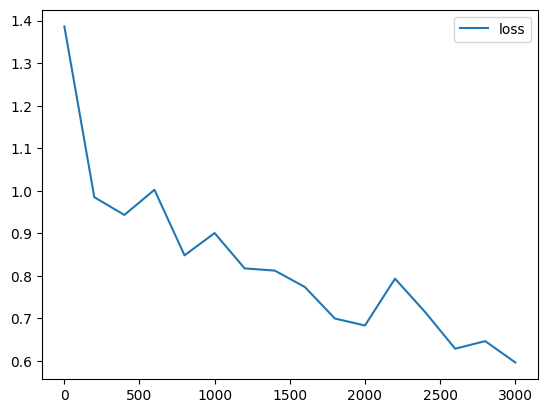

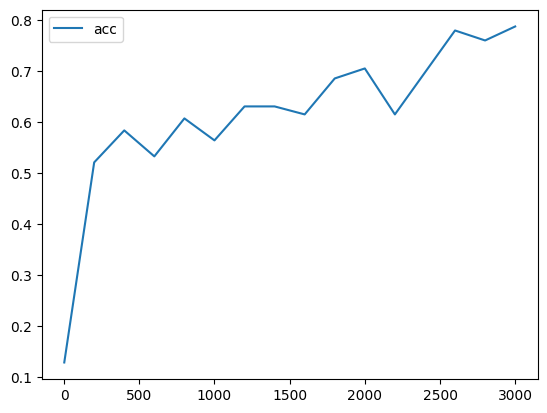

Evaluating on test set...
Test set accuracy: 0.7361  (943/1281)


In [11]:
# logistic_image_classifier.py
# Run with: python logistic_image_classifier.py
# Requirements: tensorflow (2.x), numpy, pillow (optional for reading), tqdm (optional)
# e.g. pip install tensorflow numpy pillow tqdm



# --- Config ---
DATA_ROOT = "/root/.cache/kagglehub/datasets/uraninjo/augmented-alzheimer-mri-dataset/versions/1/OriginalDataset"   # folder containing the 4 class folders
IMG_H = 176
IMG_W = 208
CHANNELS = 1                    # grayscale
FLATTENED_SIZE = IMG_H * IMG_W  # 36608
BATCH_SIZE = 256
TRAIN_TEST_SPLIT = 0.8          # 80% train, 20% test
STEPS = 3000
PRINT_EVERY = 200
LEARNING_RATE = 0.001
NUM_CLASSES = 4
SEED = 42

# set seeds for reproducibility
np.random.seed(SEED)
tf.random.set_seed(SEED)

# --- Label mapping (you can change the numeric mapping if desired) ---
class_names = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
label_to_index = {name: idx for idx, name in enumerate(class_names)}
print("Label mapping:", label_to_index)

# --- Collect file paths and labels ---
filepaths = []
labels = []

for cname in class_names:
    folder = os.path.join(DATA_ROOT, cname)
    pattern = os.path.join(folder, "*.jpg")  # adjust if images have other extensions
    files = glob.glob(pattern)
    print(f"Found {len(files)} images in {folder}")
    for f in files:
        filepaths.append(f)
        labels.append(label_to_index[cname])

if len(filepaths) == 0:
    raise RuntimeError(f"No image files found under {DATA_ROOT}. Check the path and extensions.")

filepaths = np.array(filepaths)
labels = np.array(labels)

train_files = []
train_labels = []
test_files = []
test_labels = []

for class_idx in range(NUM_CLASSES):
    # get indices for this class
    class_indices = np.where(labels == class_idx)[0]

    # shuffle indices within the class
    np.random.shuffle(class_indices)

    # compute split index for this class
    split_idx = int(len(class_indices) * TRAIN_TEST_SPLIT)

    # split
    train_idx = class_indices[:split_idx]
    test_idx = class_indices[split_idx:]

    # append
    train_files.extend(filepaths[train_idx])
    train_labels.extend(labels[train_idx])

    test_files.extend(filepaths[test_idx])
    test_labels.extend(labels[test_idx])

# convert back to numpy arrays
train_files = np.array(train_files)
train_labels = np.array(train_labels)
test_files = np.array(test_files)
test_labels = np.array(test_labels)

# final shuffle (optional but recommended)
train_perm = np.random.permutation(len(train_files))
test_perm = np.random.permutation(len(test_files))

train_files = train_files[train_perm]
train_labels = train_labels[train_perm]
test_files = test_files[test_perm]
test_labels = test_labels[test_perm]

print("Stratified split summary:")
for cname, idx in label_to_index.items():
    print(
        f"{cname:18s} | "
        f"Train: {np.sum(train_labels == idx):4d}, "
        f"Test: {np.sum(test_labels == idx):4d}"
    )

print(f"Total Train: {len(train_files)}, Total Test: {len(test_files)}")


# --- Preprocessing function ---
def load_and_preprocess(path, label):
    """
    Input:
      path: string tensor path to jpg
      label: int label
    Returns:
      image_flat: float32 tensor shape [FLATTENED_SIZE]
      label: int tensor
    """
    # read file
    image_bytes = tf.io.read_file(path)
    # decode as JPEG with single channel (grayscale)
    img = tf.image.decode_jpeg(image_bytes, channels=1)  # shape [H, W, 1], dtype uint8
    # ensure size (if images are already 176x208 this is a no-op; keeps safe)
    img = tf.image.resize(img, [IMG_H, IMG_W], method=tf.image.ResizeMethod.BILINEAR)
    # cast and normalize
    img = tf.cast(img, tf.float32) / 255.0  # [0,1]
    # flatten to vector length 36608
    img = tf.reshape(img, [FLATTENED_SIZE])  # shape (36608,)

    label = tf.cast(label, tf.int32)
    return img, label

# Create tf.data datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_files, train_labels))
train_ds = train_ds.shuffle(buffer_size=len(train_files), seed=SEED)
train_ds = train_ds.map(lambda p, l: load_and_preprocess(p, l), num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_files, test_labels))
test_ds = test_ds.map(lambda p, l: load_and_preprocess(p, l), num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# --- Build logistic regression model (weights and bias) ---
# We'll implement logits = X @ W + b where W shape [FLATTENED_SIZE, NUM_CLASSES], b shape [NUM_CLASSES]
W = tf.Variable(tf.zeros([FLATTENED_SIZE, NUM_CLASSES], dtype=tf.float32), name="W")
b = tf.Variable(tf.zeros([NUM_CLASSES], dtype=tf.float32), name="b")

optimizer = tf.keras.optimizers.SGD(learning_rate=LEARNING_RATE)

# Loss function: softmax cross-entropy
def compute_loss_and_accuracy(x_batch, y_batch):
    """
    x_batch: [batch, FLATTENED_SIZE] float32
    y_batch: [batch] int32
    returns: loss scalar, accuracy scalar
    """
    logits = tf.matmul(x_batch, W) + b  # [batch, NUM_CLASSES]
    # one-hot encode labels
    y_onehot = tf.one_hot(y_batch, depth=NUM_CLASSES)
    # cross entropy
    loss_per_example = tf.nn.softmax_cross_entropy_with_logits(labels=y_onehot, logits=logits)
    loss = tf.reduce_mean(loss_per_example)
    # accuracy
    preds = tf.argmax(logits, axis=1, output_type=tf.int32)
    acc = tf.reduce_mean(tf.cast(tf.equal(preds, y_batch), tf.float32))
    return loss, acc

# Training loop
graph_loss = []
graph_acc = []
steps_list = [] # Renamed from 'step' to 'steps_list'
print("\nStarting training...")
train_iter = iter(train_ds.repeat())  # repeat to supply STEPS batches even if dataset smaller

for step in range(1, STEPS + 1):
    try:
        x_batch, y_batch = next(train_iter)
    except StopIteration:
        # Shouldn't happen because of repeat(), but safe fallback
        train_iter = iter(train_ds.repeat())
        x_batch, y_batch = next(train_iter)

    # gradient step
    with tf.GradientTape() as tape:
        loss, acc = compute_loss_and_accuracy(x_batch, y_batch)
    grads = tape.gradient(loss, [W, b])
    optimizer.apply_gradients(zip(grads, [W, b]))

    if step % PRINT_EVERY == 0 or step == 1:
        # We already computed loss/acc for this batch; print them
        print(f"Step {step:4d}/{STEPS}  Loss: {loss.numpy():.4f}  Train batch acc: {acc.numpy():.4f}")
        graph_loss.append(loss.numpy())
        graph_acc.append(acc.numpy())
        steps_list.append(step) # Appending to 'steps_list'

print("Training complete.\n")
graph_loss = np.array(graph_loss)
graph_acc = np.array(graph_acc)
steps_list = np.array(steps_list) # Using 'steps_list'
plt.plot(steps_list, graph_loss, label="loss") # Using 'steps_list'
plt.legend()
plt.show()
plt.plot(steps_list, graph_acc, label="acc") # Using 'steps_list'
plt.legend()
plt.show()

# --- Validate on test dataset ---
print("Evaluating on test set...")
total_correct = 0
total_seen = 0
for x_batch, y_batch in test_ds:
    logits = tf.matmul(x_batch, W) + b
    preds = tf.argmax(logits, axis=1, output_type=tf.int32)
    total_correct += int(tf.reduce_sum(tf.cast(tf.equal(preds, y_batch), tf.int32)).numpy())
    total_seen += x_batch.shape[0]

test_accuracy = total_correct / total_seen
print(f"Test set accuracy: {test_accuracy:.4f}  ({total_correct}/{total_seen})")

Using Augmented Data

Label mapping: {'MildDemented': 0, 'ModerateDemented': 1, 'NonDemented': 2, 'VeryMildDemented': 3}
Found 8960 images in /root/.cache/kagglehub/datasets/uraninjo/augmented-alzheimer-mri-dataset/versions/1/AugmentedAlzheimerDataset/MildDemented
Found 6464 images in /root/.cache/kagglehub/datasets/uraninjo/augmented-alzheimer-mri-dataset/versions/1/AugmentedAlzheimerDataset/ModerateDemented
Found 9600 images in /root/.cache/kagglehub/datasets/uraninjo/augmented-alzheimer-mri-dataset/versions/1/AugmentedAlzheimerDataset/NonDemented
Found 8960 images in /root/.cache/kagglehub/datasets/uraninjo/augmented-alzheimer-mri-dataset/versions/1/AugmentedAlzheimerDataset/VeryMildDemented
Stratified split summary:
MildDemented       | Train: 7168, Test: 1792
ModerateDemented   | Train: 5171, Test: 1293
NonDemented        | Train: 7680, Test: 1920
VeryMildDemented   | Train: 7168, Test: 1792
Total Train: 27187, Total Test: 6797

Starting training...
Step    1/2500  Loss: 1.3863  Train batch acc: 0.2500

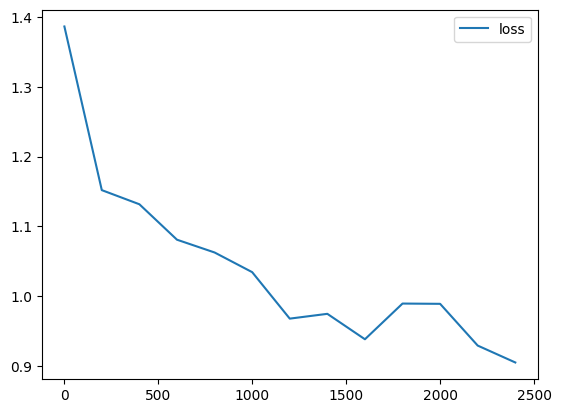

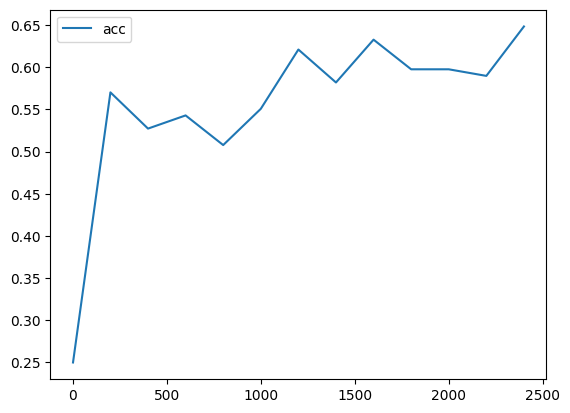

Evaluating on test set...
Test set accuracy: 0.5970  (4058/6797)


In [19]:
# --- Config ---
DATA_ROOT = "/root/.cache/kagglehub/datasets/uraninjo/augmented-alzheimer-mri-dataset/versions/1/AugmentedAlzheimerDataset"   # folder containing the 4 class folders
IMG_H = 176
IMG_W = 208
CHANNELS = 1                    # grayscale
FLATTENED_SIZE = IMG_H * IMG_W  # 36608
BATCH_SIZE = 256
TRAIN_TEST_SPLIT = 0.8          # 80% train, 20% test
STEPS = 2500
PRINT_EVERY = 200
LEARNING_RATE = 0.001
NUM_CLASSES = 4
SEED = 42

# set seeds for reproducibility
np.random.seed(SEED)
tf.random.set_seed(SEED)

# --- Label mapping (you can change the numeric mapping if desired) ---
class_names = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
label_to_index = {name: idx for idx, name in enumerate(class_names)}
print("Label mapping:", label_to_index)

# --- Collect file paths and labels ---
filepaths = []
labels = []

for cname in class_names:
    folder = os.path.join(DATA_ROOT, cname)
    pattern = os.path.join(folder, "*.jpg")  # adjust if images have other extensions
    files = glob.glob(pattern)
    print(f"Found {len(files)} images in {folder}")
    for f in files:
        filepaths.append(f)
        labels.append(label_to_index[cname])

if len(filepaths) == 0:
    raise RuntimeError(f"No image files found under {DATA_ROOT}. Check the path and extensions.")

filepaths = np.array(filepaths)
labels = np.array(labels)

train_files = []
train_labels = []
test_files = []
test_labels = []

for class_idx in range(NUM_CLASSES):
    # get indices for this class
    class_indices = np.where(labels == class_idx)[0]

    # shuffle indices within the class
    np.random.shuffle(class_indices)

    # compute split index for this class
    split_idx = int(len(class_indices) * TRAIN_TEST_SPLIT)

    # split
    train_idx = class_indices[:split_idx]
    test_idx = class_indices[split_idx:]

    # append
    train_files.extend(filepaths[train_idx])
    train_labels.extend(labels[train_idx])

    test_files.extend(filepaths[test_idx])
    test_labels.extend(labels[test_idx])

# convert back to numpy arrays
train_files = np.array(train_files)
train_labels = np.array(train_labels)
test_files = np.array(test_files)
test_labels = np.array(test_labels)

# final shuffle (optional but recommended)
train_perm = np.random.permutation(len(train_files))
test_perm = np.random.permutation(len(test_files))

train_files = train_files[train_perm]
train_labels = train_labels[train_perm]
test_files = test_files[test_perm]
test_labels = test_labels[test_perm]

print("Stratified split summary:")
for cname, idx in label_to_index.items():
    print(
        f"{cname:18s} | "
        f"Train: {np.sum(train_labels == idx):4d}, "
        f"Test: {np.sum(test_labels == idx):4d}"
    )

print(f"Total Train: {len(train_files)}, Total Test: {len(test_files)}")


# --- Preprocessing function ---
def load_and_preprocess(path, label):
    """
    Input:
      path: string tensor path to jpg
      label: int label
    Returns:
      image_flat: float32 tensor shape [FLATTENED_SIZE]
      label: int tensor
    """
    # read file
    image_bytes = tf.io.read_file(path)
    # decode as JPEG with single channel (grayscale)
    img = tf.image.decode_jpeg(image_bytes, channels=1)  # shape [H, W, 1], dtype uint8
    # ensure size (if images are already 176x208 this is a no-op; keeps safe)
    img = tf.image.resize(img, [IMG_H, IMG_W], method=tf.image.ResizeMethod.BILINEAR)
    # cast and normalize
    img = tf.cast(img, tf.float32) / 255.0  # [0,1]
    # flatten to vector length 36608
    img = tf.reshape(img, [FLATTENED_SIZE])  # shape (36608,)

    label = tf.cast(label, tf.int32)
    return img, label

# Create tf.data datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_files, train_labels))
train_ds = train_ds.shuffle(buffer_size=len(train_files), seed=SEED)
train_ds = train_ds.map(lambda p, l: load_and_preprocess(p, l), num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_files, test_labels))
test_ds = test_ds.map(lambda p, l: load_and_preprocess(p, l), num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# --- Build logistic regression model (weights and bias) ---
# We'll implement logits = X @ W + b where W shape [FLATTENED_SIZE, NUM_CLASSES], b shape [NUM_CLASSES]
W = tf.Variable(tf.zeros([FLATTENED_SIZE, NUM_CLASSES], dtype=tf.float32), name="W")
b = tf.Variable(tf.zeros([NUM_CLASSES], dtype=tf.float32), name="b")

optimizer = tf.keras.optimizers.SGD(learning_rate=LEARNING_RATE)

# Loss function: softmax cross-entropy
def compute_loss_and_accuracy(x_batch, y_batch):
    """
    x_batch: [batch, FLATTENED_SIZE] float32
    y_batch: [batch] int32
    returns: loss scalar, accuracy scalar
    """
    logits = tf.matmul(x_batch, W) + b  # [batch, NUM_CLASSES]
    # one-hot encode labels
    y_onehot = tf.one_hot(y_batch, depth=NUM_CLASSES)
    # cross entropy
    loss_per_example = tf.nn.softmax_cross_entropy_with_logits(labels=y_onehot, logits=logits)
    loss = tf.reduce_mean(loss_per_example)
    # accuracy
    preds = tf.argmax(logits, axis=1, output_type=tf.int32)
    acc = tf.reduce_mean(tf.cast(tf.equal(preds, y_batch), tf.float32))
    return loss, acc

# Training loop
graph_loss = []
graph_acc = []
steps_list = [] # Renamed from 'step' to 'steps_list'
print("\nStarting training...")
train_iter = iter(train_ds.repeat())  # repeat to supply STEPS batches even if dataset smaller

for step in range(1, STEPS + 1):
    try:
        x_batch, y_batch = next(train_iter)
    except StopIteration:
        # Shouldn't happen because of repeat(), but safe fallback
        train_iter = iter(train_ds.repeat())
        x_batch, y_batch = next(train_iter)

    # gradient step
    with tf.GradientTape() as tape:
        loss, acc = compute_loss_and_accuracy(x_batch, y_batch)
    grads = tape.gradient(loss, [W, b])
    optimizer.apply_gradients(zip(grads, [W, b]))

    if step % PRINT_EVERY == 0 or step == 1:
        # We already computed loss/acc for this batch; print them
        print(f"Step {step:4d}/{STEPS}  Loss: {loss.numpy():.4f}  Train batch acc: {acc.numpy():.4f}")
        graph_loss.append(loss.numpy())
        graph_acc.append(acc.numpy())
        steps_list.append(step) # Appending to 'steps_list'

print("Training complete.\n")
graph_loss = np.array(graph_loss)
graph_acc = np.array(graph_acc)
steps_list = np.array(steps_list) # Using 'steps_list'
plt.plot(steps_list, graph_loss, label="loss") # Using 'steps_list'
plt.legend()
plt.show()
plt.plot(steps_list, graph_acc, label="acc") # Using 'steps_list'
plt.legend()
plt.show()

# --- Validate on test dataset ---
print("Evaluating on test set...")
total_correct = 0
total_seen = 0
for x_batch, y_batch in test_ds:
    logits = tf.matmul(x_batch, W) + b
    preds = tf.argmax(logits, axis=1, output_type=tf.int32)
    total_correct += int(tf.reduce_sum(tf.cast(tf.equal(preds, y_batch), tf.int32)).numpy())
    total_seen += x_batch.shape[0]

test_accuracy = total_correct / total_seen
print(f"Test set accuracy: {test_accuracy:.4f}  ({total_correct}/{total_seen})")

Using LeNet 5 CNN architecture

In [13]:
# --- Config ---
DATA_ROOT = "/kaggle/input/augmented-alzheimer-mri-dataset/OriginalDataset"   # folder containing the 4 class folders
IMG_H = 176
IMG_W = 208
CHANNELS = 1                    # grayscale
FLATTENED_SIZE = IMG_H * IMG_W  # 36608
BATCH_SIZE = 256
TRAIN_TEST_SPLIT = 0.8          # 80% train, 20% test
STEPS = 3000
PRINT_EVERY = 200
LEARNING_RATE = 0.001
NUM_CLASSES = 4
SEED = 42

# set seeds for reproducibility
np.random.seed(SEED)
tf.random.set_seed(SEED)

# --- Label mapping (you can change the numeric mapping if desired) ---
class_names = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
label_to_index = {name: idx for idx, name in enumerate(class_names)}
print("Label mapping:", label_to_index)

# --- Collect file paths and labels ---
filepaths = []
labels = []

for cname in class_names:
    folder = os.path.join(DATA_ROOT, cname)
    pattern = os.path.join(folder, "*.jpg")  # adjust if images have other extensions
    files = glob.glob(pattern)
    print(f"Found {len(files)} images in {folder}")
    for f in files:
        filepaths.append(f)
        labels.append(label_to_index[cname])

if len(filepaths) == 0:
    raise RuntimeError(f"No image files found under {DATA_ROOT}. Check the path and extensions.")

filepaths = np.array(filepaths)
labels = np.array(labels)

train_files = []
train_labels = []
test_files = []
test_labels = []

for class_idx in range(NUM_CLASSES):
    # get indices for this class
    class_indices = np.where(labels == class_idx)[0]

    # shuffle indices within the class
    np.random.shuffle(class_indices)

    # compute split index for this class
    split_idx = int(len(class_indices) * TRAIN_TEST_SPLIT)

    # split
    train_idx = class_indices[:split_idx]
    test_idx = class_indices[split_idx:]

    # append
    train_files.extend(filepaths[train_idx])
    train_labels.extend(labels[train_idx])

    test_files.extend(filepaths[test_idx])
    test_labels.extend(labels[test_idx])

# convert back to numpy arrays
train_files = np.array(train_files)
train_labels = np.array(train_labels)
test_files = np.array(test_files)
test_labels = np.array(test_labels)

# final shuffle (optional but recommended)
train_perm = np.random.permutation(len(train_files))
test_perm = np.random.permutation(len(test_files))

train_files = train_files[train_perm]
train_labels = train_labels[train_perm]
test_files = test_files[test_perm]
test_labels = test_labels[test_perm]

print("Stratified split summary:")
for cname, idx in label_to_index.items():
    print(
        f"{cname:18s} | "
        f"Train: {np.sum(train_labels == idx):4d}, "
        f"Test: {np.sum(test_labels == idx):4d}"
    )

print(f"Total Train: {len(train_files)}, Total Test: {len(test_files)}")

'''
    image_bytes = tf.io.read_file(path)
    # decode as JPEG with single channel (grayscale)
    img = tf.image.decode_jpeg(image_bytes, channels=1)  # shape [H, W, 1], dtype uint8
    # ensure size (if images are already 176x208 this is a no-op; keeps safe)
    img = tf.image.resize(img, [IMG_H, IMG_W], method=tf.image.ResizeMethod.BILINEAR)
    # cast and normalize
    img = tf.cast(img, tf.float32) / 255.0  # [0,1]
    # flatten to vector length 36608
    img = tf.reshape(img, [FLATTENED_SIZE])  # shape (36608,)

    label = tf.cast(label, tf.int32)
    return img, label
'''
# --- Preprocessing function ---
def load_and_preprocess(path, label):
    image_bytes = tf.io.read_file(path)
    img = tf.image.decode_image(image_bytes, channels=1, expand_animations=False)
    img = tf.image.resize(img, [IMG_H, IMG_W])
    img = tf.cast(img, tf.float32) / 255.0   # normalize
    label = tf.cast(label, tf.int32)
    return img, label


# Create tf.data datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_files, train_labels))
train_ds = train_ds.shuffle(buffer_size=len(train_files), seed=SEED)
train_ds = train_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_files, test_labels))
test_ds = test_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

def build_lenet5(input_shape=(176, 208, 1), num_classes=4):
    model = tf.keras.Sequential([
        # C1
        tf.keras.layers.Conv2D(
            filters=6, kernel_size=5, strides=1, padding="valid",
            activation="tanh", input_shape=input_shape
        ),
        tf.keras.layers.AveragePooling2D(pool_size=2, strides=2),

        # C3
        tf.keras.layers.Conv2D(
            filters=16, kernel_size=5, strides=1, padding="valid",
            activation="tanh"
        ),
        tf.keras.layers.AveragePooling2D(pool_size=2, strides=2),

        # Flatten
        tf.keras.layers.Flatten(),

        # C5 + F6 (fully connected)
        tf.keras.layers.Dense(120, activation="tanh"),
        tf.keras.layers.Dense(84, activation="tanh"),

        # Output
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])
    return model

model = build_lenet5(
    input_shape=(IMG_H, IMG_W, 1),
    num_classes=NUM_CLASSES
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

model.summary()


EPOCHS = 20   # start modest; increase later

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)
print("Training complete.\n")

# --- Validate on test dataset ---
test_loss, test_acc = model.evaluate(test_ds)
print(f"LeNet-5 Test Accuracy: {test_acc:.4f}")

Label mapping: {'MildDemented': 0, 'ModerateDemented': 1, 'NonDemented': 2, 'VeryMildDemented': 3}
Found 896 images in /kaggle/input/augmented-alzheimer-mri-dataset/OriginalDataset/MildDemented
Found 64 images in /kaggle/input/augmented-alzheimer-mri-dataset/OriginalDataset/ModerateDemented
Found 3200 images in /kaggle/input/augmented-alzheimer-mri-dataset/OriginalDataset/NonDemented
Found 2240 images in /kaggle/input/augmented-alzheimer-mri-dataset/OriginalDataset/VeryMildDemented
Stratified split summary:
MildDemented       | Train:  716, Test:  180
ModerateDemented   | Train:   51, Test:   13
NonDemented        | Train: 2560, Test:  640
VeryMildDemented   | Train: 1792, Test:  448
Total Train: 5119, Total Test: 1281


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 172, 204, 6)    │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_12            │ (None, 86, 102, 6)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 82, 98, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_13            │ (None, 41, 49, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 32144)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 120)            │     3,857,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 4)              │           340 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,870,476 (14.76 MB)

 Trainable params: 3,870,476 (14.76 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 410ms/step - accuracy: 0.4643 - loss: 1.2048 - val_accuracy: 0.5082 - val_loss: 1.0046
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 255ms/step - accuracy: 0.5372 - loss: 0.9772 - val_accuracy: 0.5847 - val_loss: 0.9341
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 280ms/step - accuracy: 0.5580 - loss: 0.9366 - val_accuracy: 0.5988 - val_loss: 0.8700
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 260ms/step - accuracy: 0.6167 - loss: 0.8536 - val_accuracy: 0.6159 - val_loss: 0.8302
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 345ms/step - accuracy: 0.6494 - loss: 0.7993 - val_accuracy: 0.6729 - val_loss: 0.7462
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 254ms/step - accuracy: 0.7353 - loss: 0.6732 - val_accuracy: 0.7283 - val_loss: 0.6447
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 273ms/step - accuracy: 0.8138 - loss: 0.5331 - val_accuracy: 0.7705 - val_loss: 0.5474
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 256ms/step - accuracy: 0.8491 - loss: 0.4224 - val_accuracy: 0

Using Augmented Dataset

In [19]:
# --- Config ---
DATA_ROOT = "/kaggle/input/augmented-alzheimer-mri-dataset/AugmentedAlzheimerDataset"   # folder containing the 4 class folders
IMG_H = 176
IMG_W = 208
BATCH_SIZE = 256
CHANNELS = 1                    # grayscale
FLATTENED_SIZE = IMG_H * IMG_W  # 36608
TRAIN_TEST_SPLIT = 0.8          # 80% train, 20% test
NUM_CLASSES = 4
SEED = 42

# set seeds for reproducibility
np.random.seed(SEED)
tf.random.set_seed(SEED)

# --- Label mapping (you can change the numeric mapping if desired) ---
class_names = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
label_to_index = {name: idx for idx, name in enumerate(class_names)}
print("Label mapping:", label_to_index)

# --- Collect file paths and labels ---
filepaths = []
labels = []

for cname in class_names:
    folder = os.path.join(DATA_ROOT, cname)
    pattern = os.path.join(folder, "*.jpg")  # adjust if images have other extensions
    files = glob.glob(pattern)
    print(f"Found {len(files)} images in {folder}")
    for f in files:
        filepaths.append(f)
        labels.append(label_to_index[cname])

if len(filepaths) == 0:
    raise RuntimeError(f"No image files found under {DATA_ROOT}. Check the path and extensions.")

filepaths = np.array(filepaths)
labels = np.array(labels)

train_files = []
train_labels = []
test_files = []
test_labels = []

for class_idx in range(NUM_CLASSES):
    # get indices for this class
    class_indices = np.where(labels == class_idx)[0]

    # shuffle indices within the class
    np.random.shuffle(class_indices)

    # compute split index for this class
    split_idx = int(len(class_indices) * TRAIN_TEST_SPLIT)

    # split
    train_idx = class_indices[:split_idx]
    test_idx = class_indices[split_idx:]

    # append
    train_files.extend(filepaths[train_idx])
    train_labels.extend(labels[train_idx])

    test_files.extend(filepaths[test_idx])
    test_labels.extend(labels[test_idx])

# convert back to numpy arrays
train_files = np.array(train_files)
train_labels = np.array(train_labels)
test_files = np.array(test_files)
test_labels = np.array(test_labels)

# final shuffle (optional but recommended)
train_perm = np.random.permutation(len(train_files))
test_perm = np.random.permutation(len(test_files))

train_files = train_files[train_perm]
train_labels = train_labels[train_perm]
test_files = test_files[test_perm]
test_labels = test_labels[test_perm]

print("Stratified split summary:")
for cname, idx in label_to_index.items():
    print(
        f"{cname:18s} | "
        f"Train: {np.sum(train_labels == idx):4d}, "
        f"Test: {np.sum(test_labels == idx):4d}"
    )

print(f"Total Train: {len(train_files)}, Total Test: {len(test_files)}")

'''
    image_bytes = tf.io.read_file(path)
    # decode as JPEG with single channel (grayscale)
    img = tf.image.decode_jpeg(image_bytes, channels=1)  # shape [H, W, 1], dtype uint8
    # ensure size (if images are already 176x208 this is a no-op; keeps safe)
    img = tf.image.resize(img, [IMG_H, IMG_W], method=tf.image.ResizeMethod.BILINEAR)
    # cast and normalize
    img = tf.cast(img, tf.float32) / 255.0  # [0,1]
    # flatten to vector length 36608
    img = tf.reshape(img, [FLATTENED_SIZE])  # shape (36608,)

    label = tf.cast(label, tf.int32)
    return img, label
'''
# --- Preprocessing function ---
def load_and_preprocess(path, label):
    image_bytes = tf.io.read_file(path)
    img = tf.image.decode_image(image_bytes, channels=1, expand_animations=False)
    img = tf.image.resize(img, [IMG_H, IMG_W])
    img = tf.cast(img, tf.float32) / 255.0   # normalize
    label = tf.cast(label, tf.int32)
    return img, label


# Create tf.data datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_files, train_labels))
train_ds = train_ds.shuffle(buffer_size=len(train_files), seed=SEED)
train_ds = train_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_files, test_labels))
test_ds = test_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

def build_lenet5(input_shape=(176, 208, 1), num_classes=4):
    model = tf.keras.Sequential([
        # C1
        tf.keras.layers.Conv2D(
            filters=6, kernel_size=5, strides=1, padding="valid",
            activation="tanh", input_shape=input_shape
        ),
        tf.keras.layers.AveragePooling2D(pool_size=2, strides=2),

        # C3
        tf.keras.layers.Conv2D(
            filters=16, kernel_size=5, strides=1, padding="valid",
            activation="tanh"
        ),
        tf.keras.layers.AveragePooling2D(pool_size=2, strides=2),

        # Flatten
        tf.keras.layers.Flatten(),

        # C5 + F6 (fully connected)
        tf.keras.layers.Dense(120, activation="tanh"),
        tf.keras.layers.Dense(84, activation="tanh"),

        # Output
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])
    return model

model = build_lenet5(
    input_shape=(IMG_H, IMG_W, 1),
    num_classes=NUM_CLASSES
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

model.summary()


EPOCHS = 20   # start modest; increase later

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)
print("Training complete.\n")

# --- Validate on test dataset ---
test_loss, test_acc = model.evaluate(test_ds)
print(f"LeNet-5 Test Accuracy: {test_acc:.4f}")

Label mapping: {'MildDemented': 0, 'ModerateDemented': 1, 'NonDemented': 2, 'VeryMildDemented': 3}
Found 8960 images in /kaggle/input/augmented-alzheimer-mri-dataset/AugmentedAlzheimerDataset/MildDemented
Found 6464 images in /kaggle/input/augmented-alzheimer-mri-dataset/AugmentedAlzheimerDataset/ModerateDemented
Found 9600 images in /kaggle/input/augmented-alzheimer-mri-dataset/AugmentedAlzheimerDataset/NonDemented
Found 8960 images in /kaggle/input/augmented-alzheimer-mri-dataset/AugmentedAlzheimerDataset/VeryMildDemented
Stratified split summary:
MildDemented       | Train: 7168, Test: 1792
ModerateDemented   | Train: 5171, Test: 1293
NonDemented        | Train: 7680, Test: 1920
VeryMildDemented   | Train: 7168, Test: 1792
Total Train: 27187, Total Test: 6797


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 172, 204, 6)    │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_24            │ (None, 86, 102, 6)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 82, 98, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_25            │ (None, 41, 49, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 32144)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 120)            │     3,857,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 4)              │           340 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,870,476 (14.76 MB)

 Trainable params: 3,870,476 (14.76 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 35s 299ms/step - accuracy: 0.3891 - loss: 1.4937 - val_accuracy: 0.5374 - val_loss: 0.9821
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 29s 267ms/step - accuracy: 0.5723 - loss: 0.9317 - val_accuracy: 0.6316 - val_loss: 0.8255
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 29s 269ms/step - accuracy: 0.6618 - loss: 0.7705 - val_accuracy: 0.6721 - val_loss: 0.7396
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 28s 263ms/step - accuracy: 0.7436 - loss: 0.6138 - val_accuracy: 0.7262 - val_loss: 0.6524
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 29s 271ms/step - accuracy: 0.8060 - loss: 0.4925 - val_accuracy: 0.7475 - val_loss: 0.6207
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 28s 261ms/step - accuracy: 0.8513 - loss: 0.3921 - val_accuracy: 0.7727 - val_loss: 0.5585
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 28s 258ms/step - accuracy: 0.8977 - loss: 0.2853 - val_accuracy: 0.7851 - val_loss: 0.5739
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 28s 263ms/step - accuracy: 0.9288 - loss: 0